# <center>Organizaci&oacute;n de Datos</center>
#### <center>C&aacute;tedra Ing. Rodriguez, Juan Manuel </center>

## <center>Métodos de Regresión</center>
### <center> Práctica Regresión Logística </center>

#### Links interesantes
 * pandas.pydata.org
 * scikit-yb.org
 * matplotlib.org
 * seaborn.pydata.org
 * scikit-yb.org


Importamos librerías generales

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

Importamos librerías de modelos

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV

from sklearn.model_selection import cross_val_score,cross_validate

Importamos libreía de métricas

In [ ]:
#Metricas para evaluar modelos
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, auc, log_loss

from yellowbrick.classifier import DiscriminationThreshold
from yellowbrick.classifier import ROCAUC

# Ejercicio 1: Clasificación Binaria

Cargamos el dataset sobre el cual vamos a trabajar

In [ ]:
titanic_trucho = sns.load_dataset("titanic")
titanic_trucho.shape

(891, 15)

In [ ]:
titanic_trucho.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


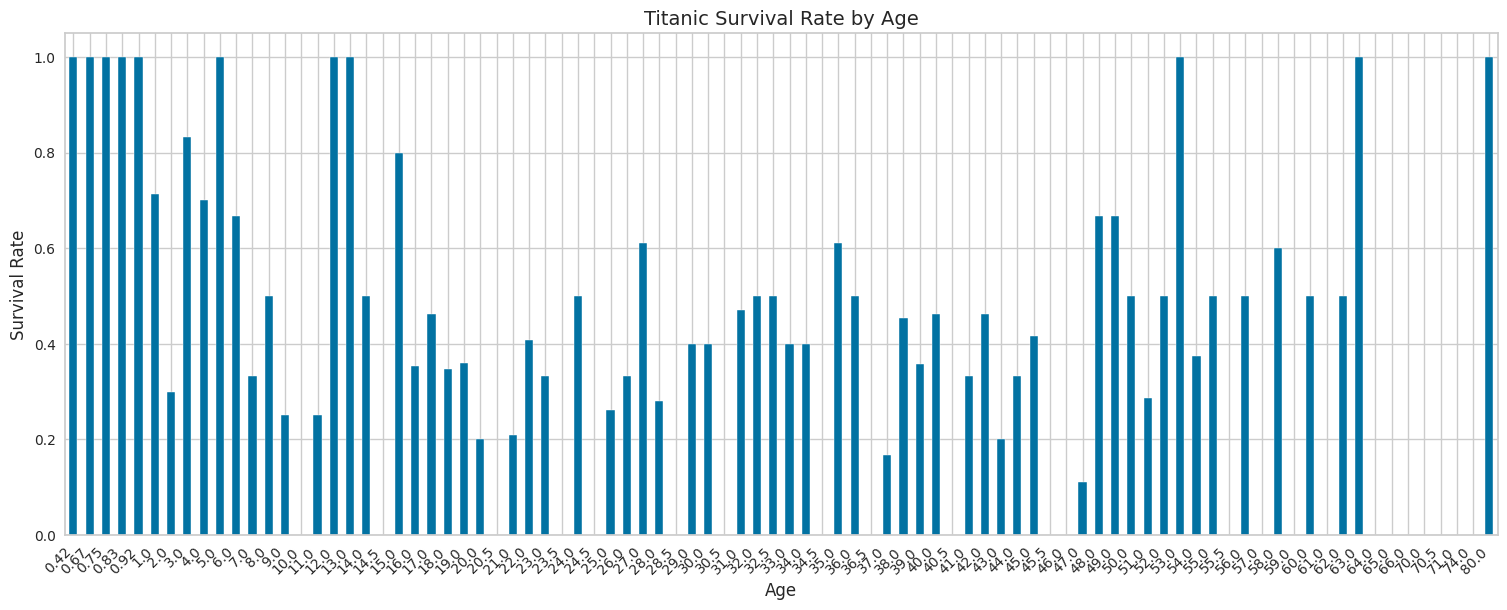

In [ ]:
plt.figure(figsize=(15, 6))
sns.set_style("whitegrid")

# Create the plot
titanic_trucho.groupby("age")["survived"].mean().sort_index().plot(kind="bar")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.xlabel("Age", fontsize=12)
plt.ylabel("Survival Rate", fontsize=12)
plt.title("Titanic Survival Rate by Age", fontsize=14)
plt.show()

In [ ]:
# Fill NaNs only for numeric columns
numeric_columns = titanic_trucho.select_dtypes(include=['float64', 'int64']).columns
titanic_trucho[numeric_columns] = titanic_trucho[numeric_columns].fillna(titanic_trucho[numeric_columns].mean())

In [ ]:
titanic_trucho.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
ds_train=pd.read_csv('/content/ds_titanic.csv')
ds_trabajo=ds_train.copy()

## Análisis exploratorio

Listamos la cantidad de filas y columnas que tiene el dataset

In [ ]:
ds_trabajo.shape

(891, 12)

Listamos los nombres de las columnas del dataset

In [ ]:
ds_trabajo.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

<b>Descripción de los campos</b><br>
PassengerId: Identificador del pasajero dentro de la tabla<br>
Survived: Indica si el pasajero sobrevivió<br>
Pclass: clase de pasajero primera(1), segunda (2) o tercera (3) <br>
Name: Nombre del pasajero <br>
Sex: Sexo del pasajero<br>
Age: Edad<br>
SibSp: Cantidad de hermanas/os o esposas/os a bordo<br>
Parch: Cantidad de padres o hijos a bordo<br>
Ticket: Número de ticket<br>
Fate: Tarifa <br>
Cabin: Cabina en la cual se encuentra alojado el pasajero<br>
Embarked: Puerta de embarque<br>

Mostramos algunas filas del dataframe

In [ ]:
ds_trabajo.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



### <font color='red'>To do (tarea) </font>
##### <font color='red'> Continuar con el análisis exploratorio  </font>    

## Preprocesamiento

Si bien ya explicamos todos los conceptos necesarios para realizar un preprocesamiento de datos exhaustivo, en esta notebook vamos a realizar muchas simplificaciones </font>

Eliminamos algunas columnas que decidimos no utilizar

In [ ]:
columnas_eliminar=['PassengerId','Name',"Ticket"]
ds_trabajo.drop(columnas_eliminar, axis='columns', inplace=True)  #Elimina columna sobre el mismo dataframe
ds_trabajo.columns.tolist()

['Survived',
 'Pclass',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Cabin',
 'Embarked']

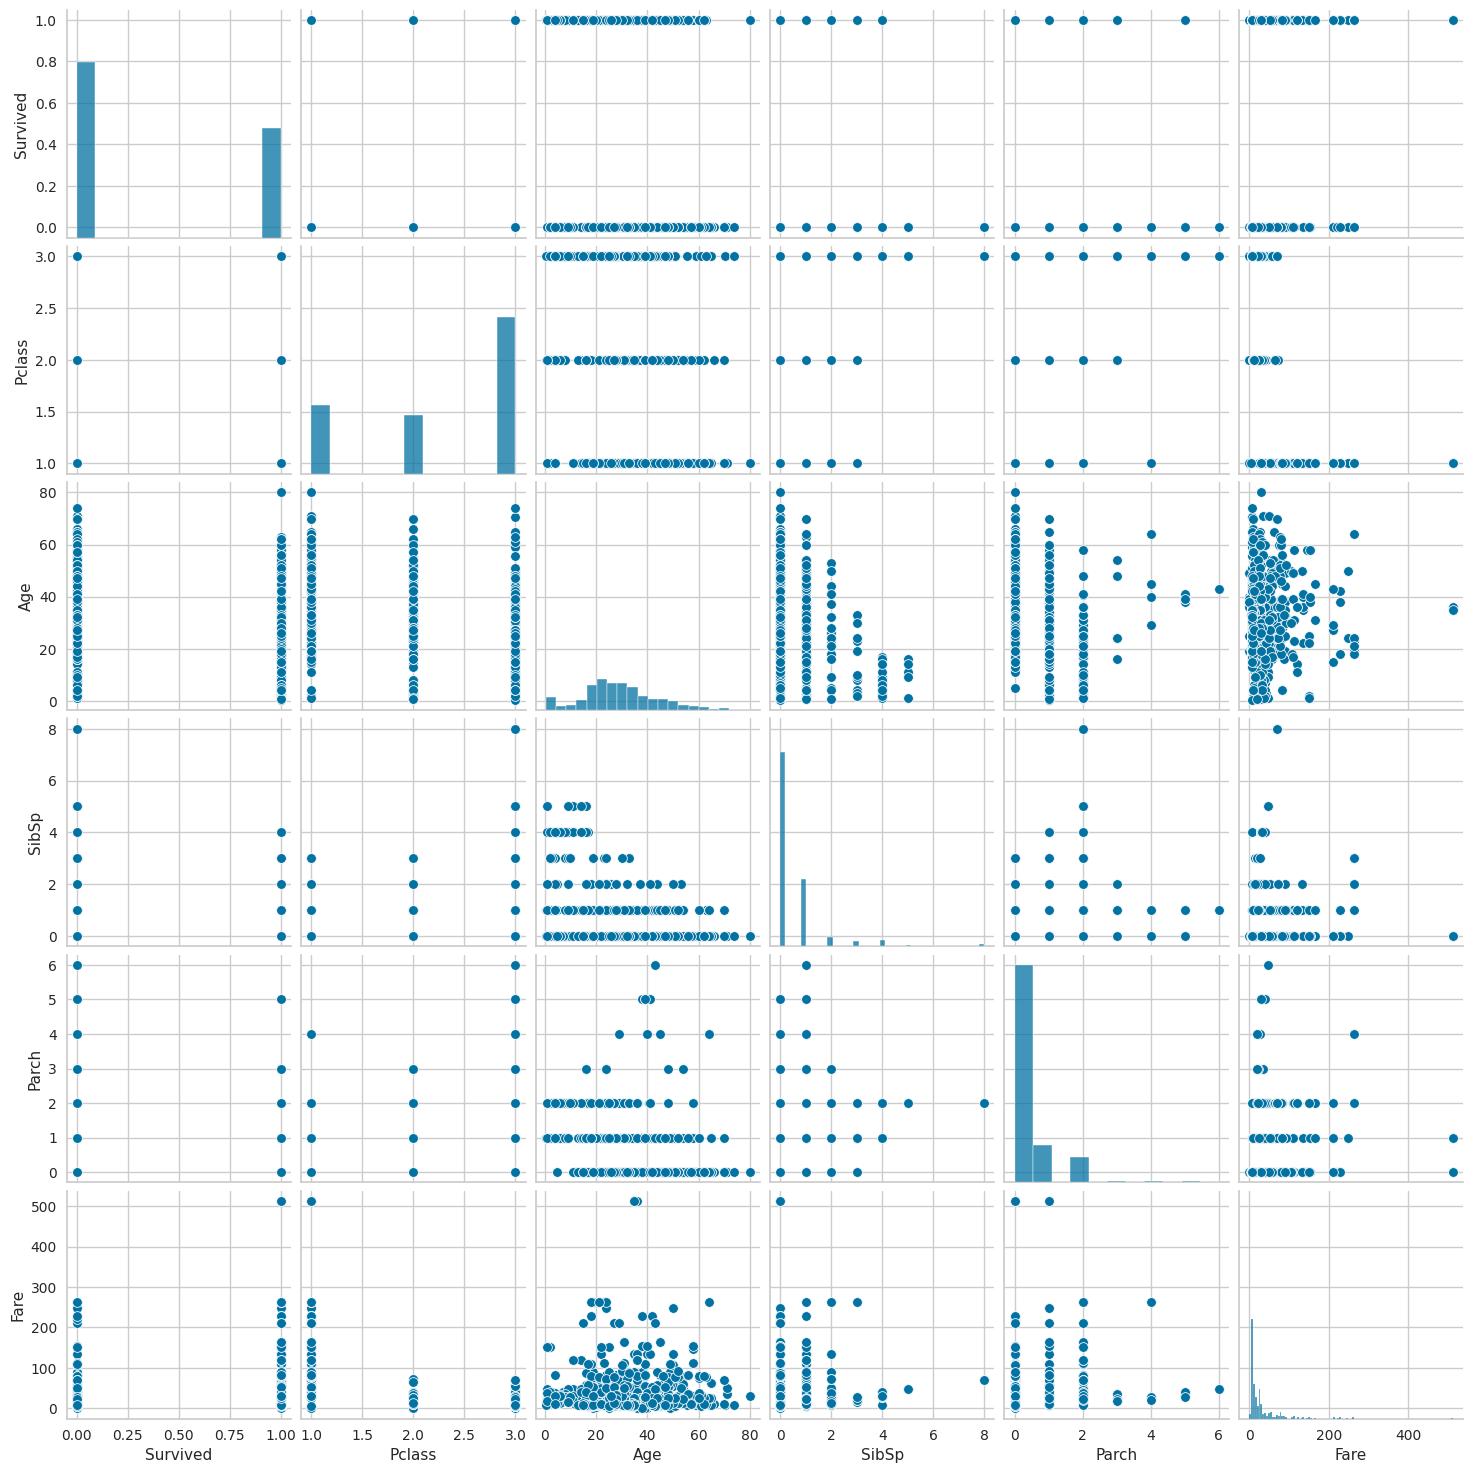

In [ ]:
#Grafico un pairplot
sns.pairplot(ds_trabajo)
plt.show()

<Figure size 2000x2000 with 0 Axes>

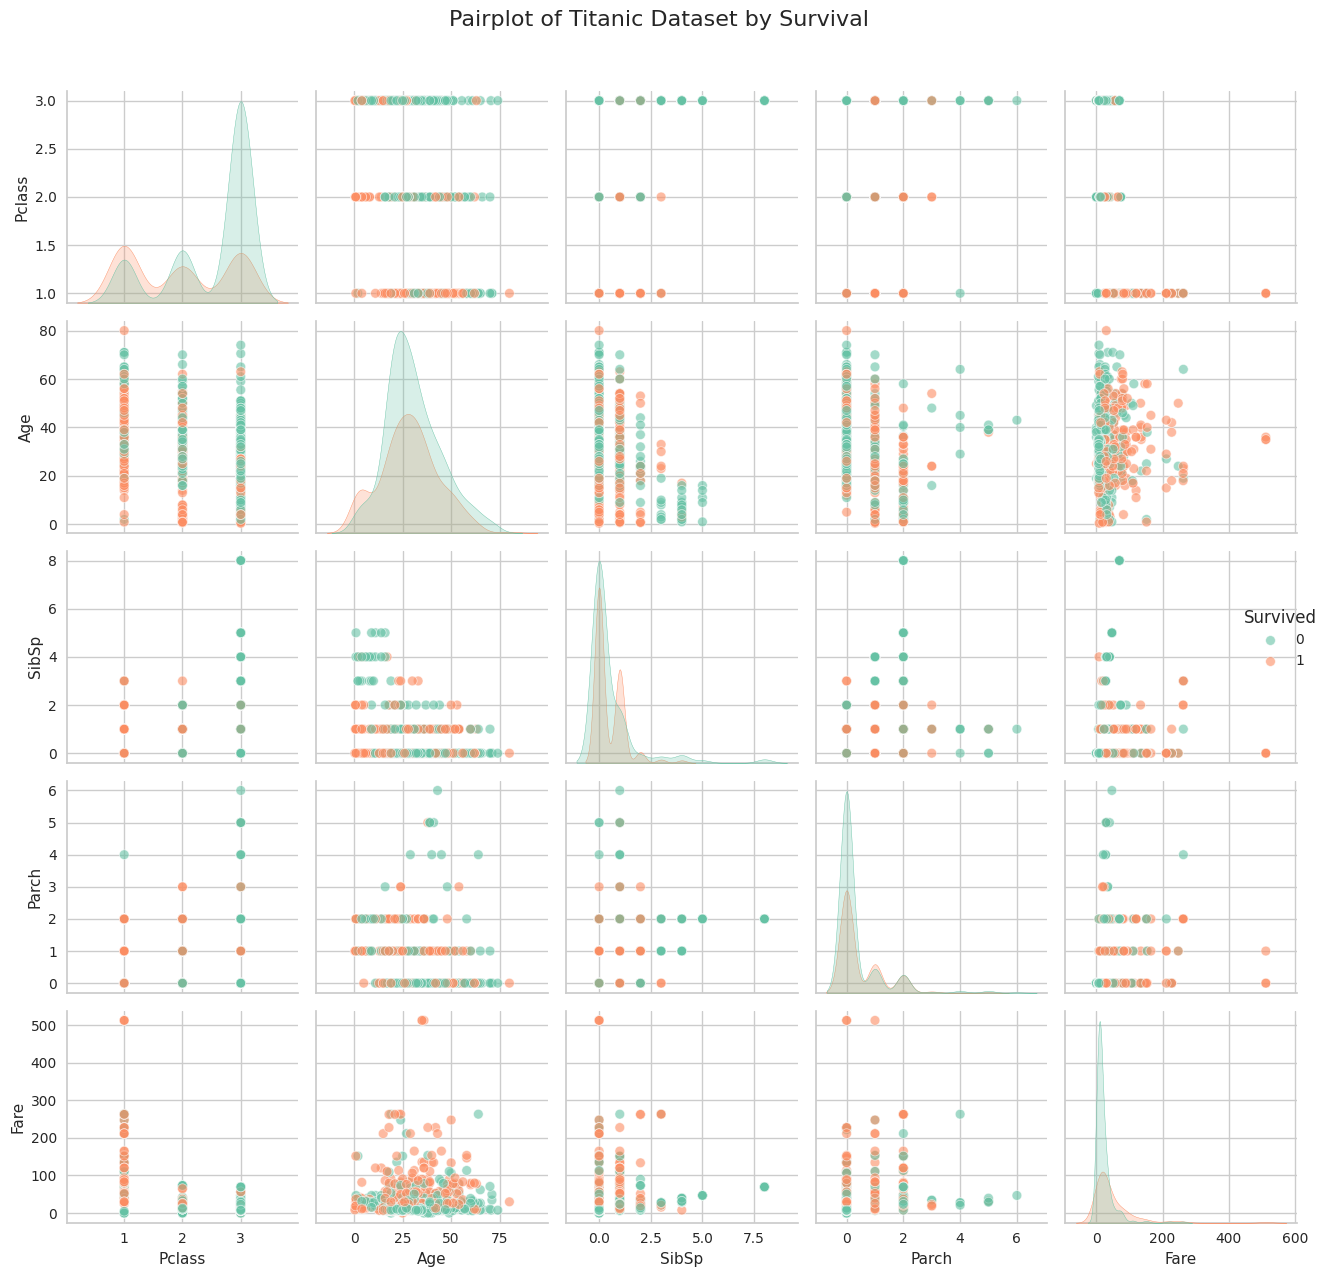

In [ ]:
plt.figure(figsize=(20, 20))

# Create pairplot with explicit color mapping
g = sns.pairplot(ds_trabajo,
                 hue='Survived',
                 diag_kind='kde',
                 plot_kws={'alpha': 0.6},
                 palette='Set2')

# Get the unique values of Survived
survived_values = sorted(ds_trabajo['Survived'].unique())

# Get handles and labels directly from the plot
handles, _ = plt.gca().get_legend_handles_labels()

# Create custom legend
plt.legend(handles,
           [f'Non-Survivors ({survived_values[0]})',
            f'Survivors ({survived_values[1]})']
           )

plt.suptitle('Pairplot of Titanic Dataset by Survival', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

#### Datos nulos

In [ ]:
filas_totales=ds_trabajo.shape[0]
print(ds_trabajo.isna().sum()/filas_totales*100)

Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Fare         0.000000
Cabin       77.104377
Embarked     0.224467
dtype: float64


Debido a la gran cantidad de datos nulos en la variable Cabin se decide eliminarla. <br>
Para el resto de las variables con datos faltantes se eliminaran las filas que tengan valores nulos en alguna de ellas.

In [ ]:
columnas_eliminar_NANs=['Cabin']
ds_trabajo.drop(columnas_eliminar_NANs, axis='columns', inplace=True)
ds_trabajo.columns.tolist()

['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

In [ ]:
ds_trabajo=ds_trabajo.dropna()

Volvemos a listar la cantidad de Nans

In [ ]:
filas_totales=ds_trabajo.shape[0]
print(ds_trabajo.isna().sum()/filas_totales*100)

Survived    0.0
Pclass      0.0
Sex         0.0
Age         0.0
SibSp       0.0
Parch       0.0
Fare        0.0
Embarked    0.0
dtype: float64


In [ ]:
ds_trabajo.shape

(712, 8)

In [ ]:
ds_trabajo.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


Continuamos trabajando con un dataset de 712 filas y 8 variables

 Muchas veces para trabajar con determinados m&eacute;todos es necesario realizar transformaciones de variables.<br>
En este caso al utilizar Regresión Logística, y querer utilizar variables categ&oacute;ricas como variables predictoras, necesitamos realizar transformaciones sobre las mismas.<br>
Realizaremos one hot encoding

In [ ]:
ds_trabajo = pd.get_dummies(ds_trabajo, columns=["Pclass","Sex","Embarked"])
ds_trabajo.head()

,Survived,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,22.0,1,0,7.2500,False,False,True,False,True,False,False,True
1,1,38.0,1,0,71.2833,True,False,False,True,False,True,False,False
2,1,26.0,0,0,7.9250,False,False,True,True,False,False,False,True
3,1,35.0,1,0,53.1000,True,False,False,True,False,False,False,True
4,0,35.0,0,0,8.0500,False,False,True,False,True,False,False,True


Buscamos filas repetidas

In [ ]:
ds_trabajo_dup = ds_trabajo[ds_trabajo.duplicated(keep=False)]
ds_trabajo_dup.head()

,Survived,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
4,0,35.0,0,0,8.0500,False,False,True,False,True,False,False,True
37,0,21.0,0,0,8.0500,False,False,True,False,True,False,False,True
53,1,29.0,1,0,26.0000,False,True,False,True,False,False,False,True
74,1,32.0,0,0,56.4958,False,False,True,False,True,False,False,True
91,0,20.0,0,0,7.8542,False,False,True,False,True,False,False,True


In [ ]:
ds_trabajo.drop_duplicates(inplace=True)

In [ ]:
ds_trabajo.shape

(674, 13)

#### Divisi&oacute;n Train - Test

Dividimos en conjunto de datos inicial, en dos subconjuntos. <br>
Uno destinado a entrenar el modelo y otro para probarlo sobre datos que no vio <br>
En este caso vamos a entrenar utilizando el 80% de los datos y validando los modelos sobre el 20% de datos restantes.

In [ ]:
columnas_modelo = ds_trabajo.columns.tolist()
columnas_modelo.remove('Survived')

ds_trabajo_x = ds_trabajo[columnas_modelo].copy()
ds_trabajo_y = ds_trabajo['Survived'].copy()

x_train, x_test, y_train, y_test = train_test_split(ds_trabajo_x, ds_trabajo_y, test_size=0.2, random_state=2)

#### Comparamos la distribución de la variable Survived

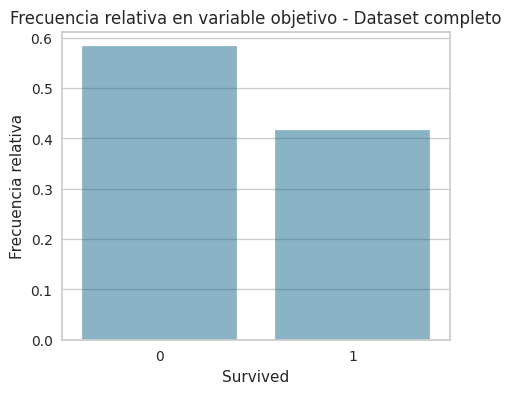

In [ ]:
ds_agrupado_survived=ds_agrupado_Pclass=ds_trabajo.groupby(['Survived']).count()  #Calculo la frecuencia de cada categoría
cant_total=ds_trabajo.shape[0]

## Declaramos valores para los ejes
eje_x = ds_agrupado_survived.index.tolist()
eje_y = [i/cant_total for i in ds_agrupado_survived['Age'].tolist()]

plt.figure(figsize=(5, 4))
sns_bar_plot=sns.barplot(x=eje_x, y=eje_y, data=ds_agrupado_survived ,alpha=0.5).set(title="Frecuencia relativa en variable objetivo - Dataset completo",ylabel='Frecuencia relativa',xlabel='Survived')
plt.show()

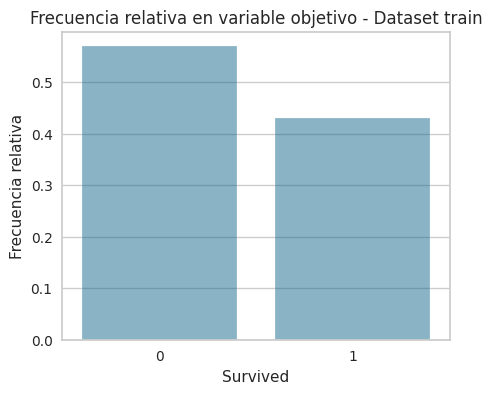

In [ ]:
ds_aux=pd.DataFrame(list(zip(y_train)),columns=["Survived"]).reset_index()
ds_agrupado_survived=ds_aux.groupby(['Survived']).count()  #Calculo la frecuencia de cada categoría
cant_total=ds_aux.shape[0]

## Declaramos valores para los ejes
eje_x = ds_agrupado_survived.index.tolist()
eje_y = [ i/cant_total for i in ds_agrupado_survived['index'].tolist()]

plt.figure(figsize=(5, 4))
sns_bar_plot=sns.barplot(x=eje_x, y=eje_y, data=ds_agrupado_survived ,alpha=0.5).set(title="Frecuencia relativa en variable objetivo - Dataset train",ylabel='Frecuencia relativa',xlabel='Survived')
plt.show()

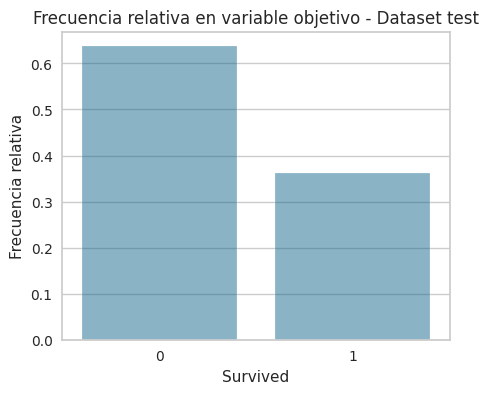

In [ ]:
ds_aux=pd.DataFrame(list(zip(y_test)),columns=["Survived"]).reset_index()

ds_agrupado_survived=ds_aux.groupby(['Survived']).count()  #Calculo la frecuencia de cada categoría
ds_agrupado_survived.head()

cant_total=y_test.shape[0]
eje_x = ds_agrupado_survived.index.tolist()   ## Declaramos valores para el eje x
eje_y = [ i/cant_total for i in ds_agrupado_survived['index'].tolist()]  ## Declaramos valores para el eje y

plt.figure(figsize=(5, 4))
sns_bar_plot=sns.barplot(x=eje_x, y=eje_y, data=ds_agrupado_survived ,alpha=0.5).set(title="Frecuencia relativa en variable objetivo - Dataset test",ylabel='Frecuencia relativa',xlabel='Survived')
plt.show()

### <font color='red'>To do (tarea)</font>
##### <font color='red'> Evaluar c&oacute;mo se comportan los modelos propuestos a continuaci&oacute;n con distintas segmentaciones del dataset original en train y test  </font>    
##### <font color='red'> Probar por ejemplo: </font>   
* ##### <font color='red'> Desbalance de clases en entrenamiento (por ej 90% de las observaciones correspondiente a la clase mayoritaria) </font>   
* ##### <font color='red'> Igual cantidad de muestras en ambas clases </font>   
* ##### <font color='red'> Mayor cantidad de observaciones de la clase minoritaria </font>   

## Clasificación

##### Vamos a proponer 2 modelos

#### Modelo 1
Realizamos un modelo de regresión logística para predecir la supervivencia en función de Pclass, Sex y Age.

In [ ]:
columnas_modelo1 = ['Pclass_1','Pclass_2','Sex_female','Age']
x_train_modelo1 = x_train[columnas_modelo1].copy()
y_train_modelo1 = y_train.copy()

x_test_modelo1 = x_test[columnas_modelo1].copy()
y_test_modelo1 = y_test.copy()

 Entrenamos el modelo

In [ ]:
modelo1 = LogisticRegression()
modelo1.fit(x_train_modelo1, y_train_modelo1)

LogisticRegression()

Vemos sus coeficientes.

Recordemos que la escala de los coeficientes esta en el *logaritmo de los odds*. Por cada unidad incrementada de la variable $Xi$, se cambia el logaritmo del odds ratio de la variable target en la medida del coeficiente β.

En el caso de las variables categóricas binarias, uno de los valores que puede tomar la variable será la “categoría de referencia” (por lo general 0). Luego, cambiar la variable $X_i$ de la categoría de referencia (0) a la otra categoría (1) cambia las probabilidades estimadas por un factor de $exp(βi)$.

Cada peso ꞵi asociado a un feature $X_i$ podrá indicar cuán importante es ese feature para la clasificación.


In [ ]:
modelo1.coef_

array([[ 2.15012677,  1.15235194,  2.37149476, -0.03291617]])

In [ ]:
modelo1.intercept_

array([-1.18948758])

In [ ]:
coeficientes= pd.DataFrame(modelo1.coef_[0],
                columnas_modelo1,
                columns=['coef'])
coeficientes

,coef
Pclass_1,2.150127
Pclass_2,1.152352
Sex_female,2.371495
Age,-0.032916


Evaluamos al modelo sobre datos de test

In [ ]:
y_pred_modelo1 = modelo1.predict(x_test_modelo1)
y_pred_proba_modelo1 = modelo1.predict_proba(x_test_modelo1)[:, 1]

Existen varias m&eacute;tricas para evaluar modelos <br>
Primero miremos una tabla de contingencia

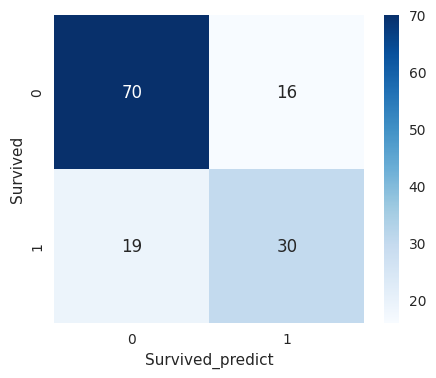

In [ ]:
ds_cm=pd.DataFrame(list(zip(y_test_modelo1, y_pred_proba_modelo1)),columns=["Survived","Prob"])
ds_cm["Survived_predict"]=0
ds_cm.loc[ds_cm.loc[:,"Prob"]>=0.50,"Survived_predict"]=1

tabla=pd.crosstab(ds_cm['Survived'], ds_cm['Survived_predict'])
plt.figure(figsize=(5, 4))
grf=sns.heatmap(tabla,annot=True, cmap = 'Blues')
plt.show()

Utilicemos AUC

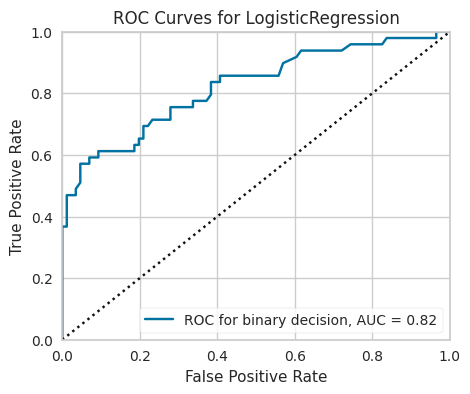

In [ ]:
visualizer = ROCAUC(modelo1,binary=True)

plt.figure(figsize=(5, 4))
visualizer.fit(x_train_modelo1, y_train_modelo1)
visualizer.score(x_test_modelo1, y_test_modelo1)

grf=visualizer.show()

#### Validacion cruzada

El dataset lo debemos dividir en 2 conjuntos de datos. <br>
Un conjunto lo utilizamos para entrenar el modelo (buscar parámetros) y el otro conjunto lo usaremos para evaluar al modelo creado <br>

A su vez el conjunto de entrenamiento se puede dividir en conjuntos de entrenamiento y validación como se observa en la siguiente figura:

<img src="https://scikit-learn.org/stable/_images/grid_search_cross_validation.png">

##### Sumemos validación cruzada
Estamos entrenando con un solo conjunto de datos, probemos usando validación cruzada

In [ ]:
modelo_cv = LogisticRegressionCV(cv=5,scoring= 'roc_auc')
modelo_cv.fit(x_train_modelo1, y_train_modelo1)

LogisticRegressionCV(cv=5, scoring='roc_auc')

In [ ]:
# Imprimir los scores de AUC para cada fold
print("AUC de los 5 folds:")
for i, auc in enumerate(modelo_cv.scores_[1], 1):
    print(f"Fold {i}: {auc}")

# Calcular el promedio y la desviación estándar
print("\nResumen de AUC:")
print(f"Promedio: {modelo_cv.scores_[1].mean()}")
print(f"Desviación estándar: {modelo_cv.scores_[1].std()}")

AUC de los 5 folds:
Fold 1: [0.59028752 0.62289621 0.79014727 0.85676718 0.85185835 0.85326087
 0.85466339 0.85466339 0.85466339 0.85466339]
Fold 2: [0.5664446  0.60396213 0.76560309 0.85255961 0.85816971 0.85431276
 0.85326087 0.85255961 0.85255961 0.85255961]
Fold 3: [0.55702825 0.58597837 0.77432857 0.88733868 0.88071155 0.87826997
 0.87757238 0.87757238 0.87757238 0.87757238]
Fold 4: [0.56365539 0.59818626 0.75514475 0.84094873 0.84722707 0.84897105
 0.84862225 0.84862225 0.84862225 0.84862225]
Fold 5: [0.52031361 0.54739843 0.69387028 0.76621525 0.79864576 0.81040627
 0.81111903 0.81111903 0.81111903 0.81111903]

Resumen de AUC:
Promedio: 0.7839951085305487
Desviación estándar: 0.11108183628747188


In [ ]:
print("Valores de C probados:")
print(modelo_cv.Cs_)

Valores de C probados:
[1.00000000e-04 7.74263683e-04 5.99484250e-03 4.64158883e-02
 3.59381366e-01 2.78255940e+00 2.15443469e+01 1.66810054e+02
 1.29154967e+03 1.00000000e+04]


In [ ]:
print("C elegido:")
print(modelo_cv.C_)

C elegido:
[21.5443469]


In [ ]:
y_pred_modelo_cv = modelo_cv.predict(x_test_modelo1)
y_pred_proba_modelo_cv = modelo_cv.predict_proba(x_test_modelo1)[:, 1]

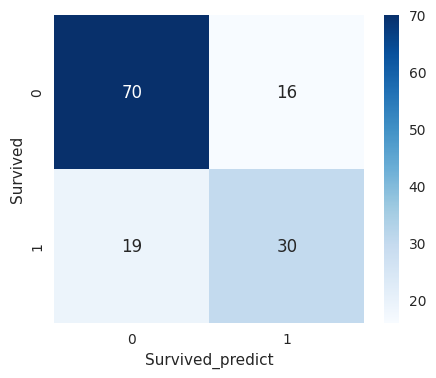

In [ ]:
ds_vc=pd.DataFrame(list(zip(y_test_modelo1, y_pred_proba_modelo_cv)),columns=["Survived","Prob"])
ds_vc["Survived_predict"]=0
ds_vc.loc[ds_cm.loc[:,"Prob"]>=0.50,"Survived_predict"]=1

tabla=pd.crosstab(ds_vc['Survived'], ds_vc['Survived_predict'])
plt.figure(figsize=(5, 4))
grf=sns.heatmap(tabla,annot=True, cmap = 'Blues')
plt.show()

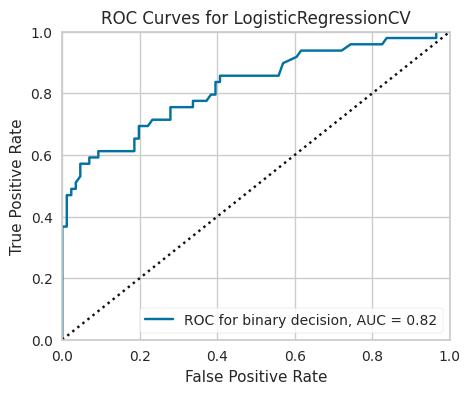

In [ ]:
visualizer = ROCAUC(modelo_cv,binary=True)

plt.figure(figsize=(5, 4))
visualizer.fit(x_train_modelo1, y_train_modelo1)
visualizer.score(x_test_modelo1, y_test_modelo1)

grf=visualizer.show()

### Modelo 2
Realizamos un modelo de regresión logística para predecir la supervivencia en función de Sex y la puerta de embarque.

In [ ]:
columnas_modelo2 = ['Sex_female','Embarked_C','Embarked_Q','Embarked_S']
x_train_modelo2 = x_train[columnas_modelo2].copy()
y_train_modelo2 = y_train.copy()

x_test_modelo2 = x_test[columnas_modelo2].copy()
y_test_modelo2 = y_test.copy()

In [ ]:
modelo2 = LogisticRegression()
modelo2.fit(x_train_modelo2, y_train_modelo2)

y_pred_modelo2 = modelo2.predict(x_test_modelo2)
y_pred_proba_modelo2 = modelo2.predict_proba(x_test_modelo2)[:, 1]

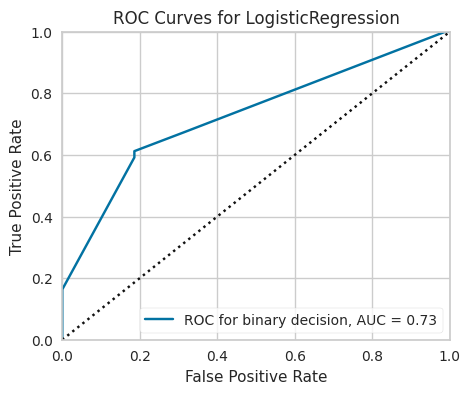

In [ ]:
visualizer = ROCAUC(modelo2,binary=True)

plt.figure(figsize=(5, 4))
visualizer.fit(x_train_modelo2, y_train_modelo2)
visualizer.score(x_test_modelo2, y_test_modelo2)
grf=visualizer.show()

##### Sumamos validación cruzada

In [ ]:
modelo_cv2 = LogisticRegressionCV(cv=5,scoring= 'roc_auc')
modelo_cv2.fit(x_train_modelo2, y_train_modelo2)

LogisticRegressionCV(cv=5, scoring='roc_auc')

In [ ]:
modelo_cv2.scores_[1].mean()

np.float64(0.7938418899397358)

In [ ]:
y_pred_modelo_cv2 = modelo_cv2.predict(x_test_modelo2)
y_pred_proba_modelo_cv2 = modelo_cv2.predict_proba(x_test_modelo2)[:, 1]

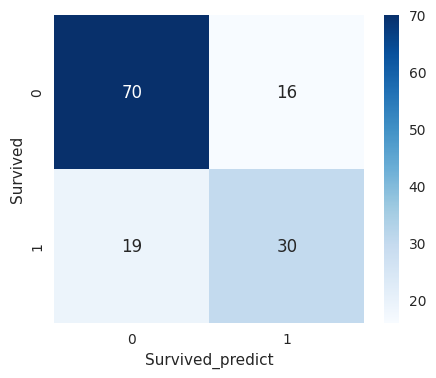

In [ ]:
ds_cv2=pd.DataFrame(list(zip(y_test_modelo2, y_pred_proba_modelo_cv2)),columns=["Survived","Prob"])
ds_cv2["Survived_predict"]=0
ds_cv2.loc[ds_cm.loc[:,"Prob"]>=0.50,"Survived_predict"]=1

tabla=pd.crosstab(ds_cv2['Survived'], ds_cv2['Survived_predict'])
plt.figure(figsize=(5, 4))
grf2=sns.heatmap(tabla,annot=True, cmap = 'Blues')
plt.show()

In [ ]:
metrics.accuracy_score(ds_cv2.Survived, ds_cv2.Survived_predict)

0.7407407407407407

In [ ]:
metrics.f1_score(ds_cv2.Survived, ds_cv2.Survived_predict)

0.631578947368421

In [ ]:
metrics.recall_score(ds_cv2.Survived, ds_cv2.Survived_predict)

0.6122448979591837

In [ ]:
metrics.precision_score(ds_cv2.Survived, ds_cv2.Survived_predict)

0.6521739130434783

# Ejercicio 12: Clasificación multiclase

In [ ]:
from sklearn.datasets import load_iris

In [ ]:
iris = load_iris()

In [ ]:
print(iris['feature_names'])

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [ ]:
nombres_columnas=[ x.replace('(cm)','').rstrip().replace(" ","_") for x in iris['feature_names']]

df_iris=pd.DataFrame(iris['data'],columns=nombres_columnas)
y_iris=iris['target']
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


<img src="https://www.pngkey.com/png/detail/82-826789_iris-iris-sepal-and-petal.png" alt="Iris - Iris Sepal And Petal@pngkey.com">

## Análisis exploratorio

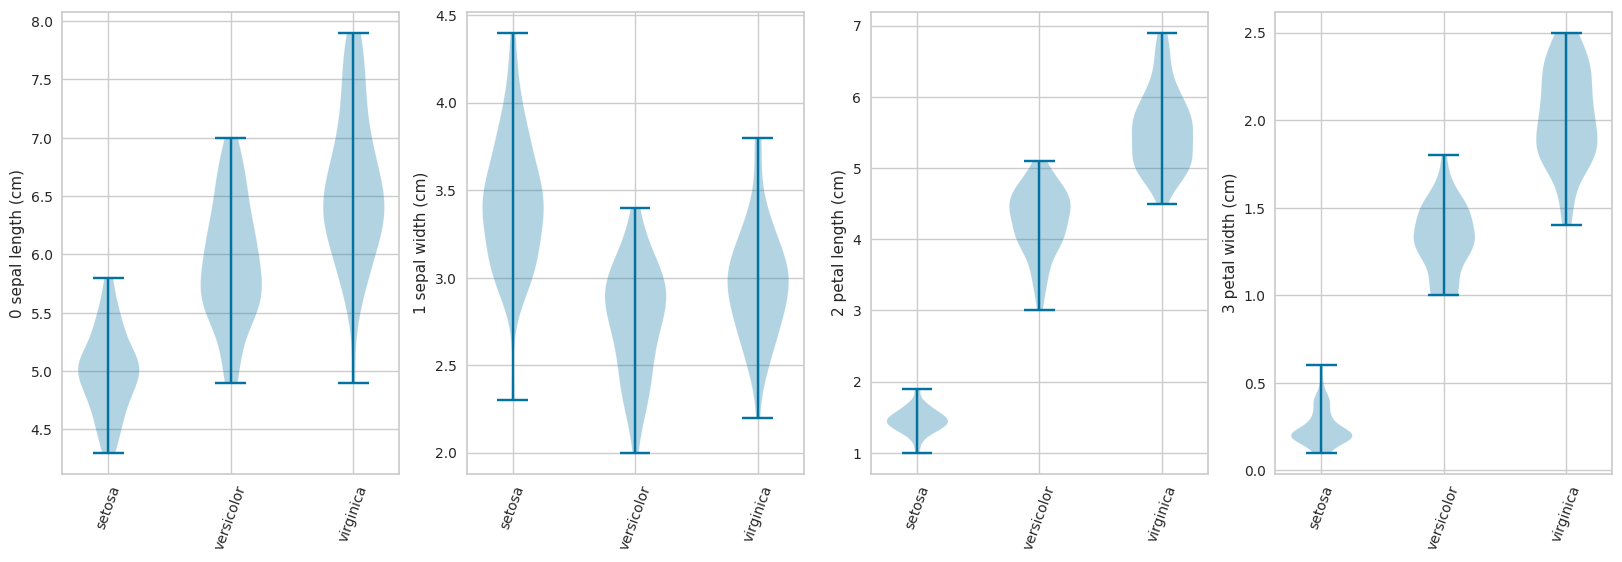

In [ ]:
plt.figure(figsize=(20, 6))

for f, f_name in enumerate(iris['feature_names']):
    plt.subplot(1,4,f+1)
    data = np.zeros((50,3))
    for k in range(3): #
        data[:,k] = iris.data[iris.target==k,f]
    plt.violinplot(data)
    plt.ylabel(str(f)+' '+ f_name)
    plt.xticks([1,2,3], labels=iris['target_names'], rotation = 70)

plt.show()

Se puede observar que la categoría Setosa se puede distinguir del resto utilizando dos atributos. <br>
Sin embargo Versicolor y Virnica no son tan fácilmente separables

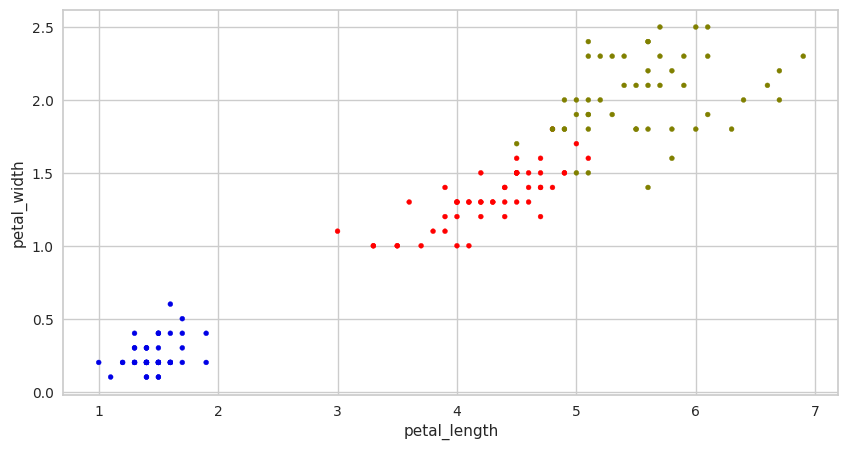

In [ ]:
color_map = {-1: (1, 1, 1), 0: (0, 0, .9), 1: (1, 0, 0), 2: (.5, .5, 0)}
colors = [color_map[y] for y in iris.target]
plt.figure(figsize=(10, 5))
plt.scatter(df_iris.petal_length,df_iris.petal_width,c=colors,marker='.')
plt.xlabel('petal_length')
plt.ylabel('petal_width')
plt.show()

Pensemos un modelo que sólo incluya estas 2 variables

In [ ]:
df_iris_2_vars=df_iris[['petal_length','petal_width']]
df_iris_2_vars.head()

,petal_length,petal_width
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


Aclaración importante: <br>
Esta vez no separamos en train-test porque estamos haciendo una prueba para entender cómo funciona el modelo

In [ ]:
clf_2_vars = LogisticRegression(multi_class='multinomial')
clf_2_vars.fit(df_iris_2_vars, y_iris)

LogisticRegression(multi_class='multinomial')

In [73]:
y_iris

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
# Buscamos los rangos de valores para los dos features y creamos una malla que cubra todo el espacio de características
x1_min, x1_max = np.min(df_iris.petal_length), np.max(df_iris.petal_length)
x2_min, x2_max = np.min(df_iris.petal_width), np.max(df_iris.petal_width)
xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.1),
                     np.arange(x2_min, x2_max, 0.1))

#Combinar las coordenadas de la malla en una única matriz para poder hacer predicciones
XX = np.c_[xx1.ravel(), xx2.ravel()]
pred = clf_2_vars.predict(XX)

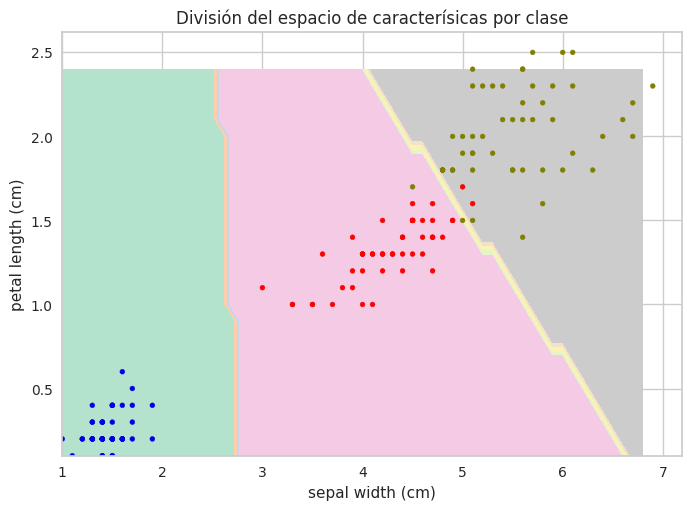

In [ ]:
plt.figure(3)
pred = pred.reshape(xx1.shape)
plt.contourf(xx1, xx2, pred, cmap=plt.cm.Pastel2)

plt.scatter(df_iris_2_vars.petal_length,df_iris_2_vars.petal_width,c = colors,marker='.')
plt.title(u'División del espacio de caracterísicas por clase')
plt.xlabel(iris['feature_names'][1])
plt.ylabel(iris['feature_names'][2])
plt.show()

## Clasificación

Creemos un modelo utilizando todas las variables y ahora si separemos en train y test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( df_iris, y_iris, test_size=0.2, random_state=1)

In [ ]:
clf_iris_rl=LogisticRegressionCV(cv=5,multi_class='multinomial')

clf_iris_rl.fit(X_train, y_train)

LogisticRegressionCV(cv=5, multi_class='multinomial')

In [ ]:
def plot_confusion_matrix(clf, X_test, y_test, y_pred, labels):
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    fig = plt.figure()
    sns.heatmap(cm, annot = True, xticklabels =labels, yticklabels = labels, cmap = 'Blues')
    plt.show()

Test confusion matrix:
[[11  0  0]
 [ 0 12  1]
 [ 0  0  6]]


<Figure size 400x400 with 0 Axes>

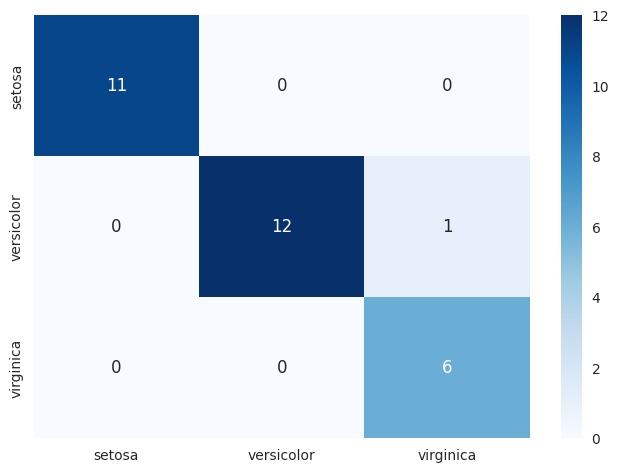

In [ ]:
from sklearn.metrics import accuracy_score

plt.figure(figsize=(4, 4))

y_pred = clf_iris_rl.predict(X_test)
print("Test confusion matrix:")
plot_confusion_matrix(clf_iris_rl, X_test, y_test, y_pred,labels=  iris['target_names'])

Calculamos las métricas

In [ ]:
metrics.accuracy_score(y_test,y_pred)

0.9666666666666667

In [ ]:
metrics.recall_score(y_test,y_pred,average='micro')

0.9666666666666667

In [ ]:
metrics.precision_score(y_test,y_pred,average='micro')

0.9666666666666667

Observar que para la clasificación multiclase tuvimos que agregar un parámetro adicional: `average='micro'`